In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader, random_split

from sklearn.cross_decomposition import CCA
from sklearn.metrics.pairwise import cosine_distances
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

import anndata as ad
import h5py

In [2]:
data_dir = "/Users/mridulav/Downloads/datapreprocessed_output"
base = "mouse_V11L12_038_B1"

X = np.load(os.path.join(data_dir, f"{base}_X_rna.npy"))
Y = np.load(os.path.join(data_dir, f"{base}_X_msi.npy"))

scaler_x = StandardScaler()
scaler_y = StandardScaler()

X = scaler_x.fit_transform(X)
Y = scaler_y.fit_transform(Y)

print(X.shape, Y.shape)

(2642, 2000) (2642, 2065)


In [3]:
latent_dim = 16

class Encoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.ReLU(),
            nn.Linear(256, latent_dim)
        )

    def forward(self, x):
        return self.net(x)


class DeepCCA(nn.Module):
    def __init__(self, G, M):
        super().__init__()
        self.gene_encoder = Encoder(G)
        self.msi_encoder = Encoder(M)

    def forward(self, x, y):
        return self.gene_encoder(x), self.msi_encoder(y)

In [4]:
def cca_loss(H1, H2, outdim_size=8):

    r = 1e-4
    eps = 1e-9

    m = H1.size(0)

    H1 = H1 - H1.mean(dim=0)
    H2 = H2 - H2.mean(dim=0)

    S11 = (H1.T @ H1) / (m - 1) + r * torch.eye(H1.size(1), device=H1.device)
    S22 = (H2.T @ H2) / (m - 1) + r * torch.eye(H2.size(1), device=H2.device)
    S12 = (H1.T @ H2) / (m - 1)

    E1, V1 = torch.linalg.eigh(S11)
    E2, V2 = torch.linalg.eigh(S22)

    S11_inv_sqrt = V1 @ torch.diag((E1 + eps).pow(-0.5)) @ V1.T
    S22_inv_sqrt = V2 @ torch.diag((E2 + eps).pow(-0.5)) @ V2.T

    T = S11_inv_sqrt @ S12 @ S22_inv_sqrt

    corr = torch.linalg.svdvals(T)[:outdim_size].sum()

    return -corr

In [5]:
device = torch.device("cpu")

X_tensor = torch.tensor(X, dtype=torch.float32)
Y_tensor = torch.tensor(Y, dtype=torch.float32)

dataset = TensorDataset(X_tensor, Y_tensor)

n_val = int(0.1 * len(dataset))
n_train = len(dataset) - n_val

train_set, val_set = random_split(
    dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_set, batch_size=512, shuffle=True)
val_loader = DataLoader(val_set, batch_size=512, shuffle=False)

model = DeepCCA(X.shape[1], Y.shape[1]).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

best_val = float("inf")

In [6]:
for epoch in range(200):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)

        optimizer.zero_grad()
        h1, h2 = model(xb, yb)

        loss = cca_loss(h1, h2)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for xb, yb in val_loader:
            xb, yb = xb.to(device), yb.to(device)
            h1, h2 = model(xb, yb)
            val_loss += cca_loss(h1, h2).item()

    val_loss /= len(val_loader)

    if val_loss < best_val:
        best_val = val_loss
        torch.save(model.state_dict(), "/Users/mridulav/best_model2.pt")

    print(epoch, train_loss, val_loss)

0 -2.65774188041687 -3.775212287902832
1 -4.4892524719238285 -4.082013130187988
2 -5.786448192596436 -4.254499435424805
3 -6.6437605857849125 -4.329136848449707
4 -7.158057498931885 -4.430075645446777
5 -7.451388931274414 -4.4316487312316895
6 -7.63742961883545 -4.476936340332031
7 -7.759677696228027 -4.508871078491211
8 -7.839938354492188 -4.484889030456543
9 -7.889783000946045 -4.478122711181641
10 -7.9223753929138185 -4.484432220458984
11 -7.945780944824219 -4.466030120849609
12 -7.96115026473999 -4.474098205566406
13 -7.970982837677002 -4.469809532165527
14 -7.978444290161133 -4.4655375480651855
15 -7.983678913116455 -4.473025321960449
16 -7.987020778656006 -4.465716361999512
17 -7.989467334747315 -4.46792459487915
18 -7.991589832305908 -4.468258857727051
19 -7.992566967010498 -4.464272975921631
20 -7.9937317848205565 -4.463778495788574
21 -7.9945228576660154 -4.465857982635498
22 -7.995372104644775 -4.464746952056885
23 -7.995805168151856 -4.464739799499512
24 -7.996403503417969 -

In [7]:
model.load_state_dict(torch.load("/Users/mridulav/best_model2.pt"))
model.eval()

H1_all, H2_all = [], []

with torch.no_grad():
    for xb, yb in DataLoader(TensorDataset(X_tensor, Y_tensor), batch_size=512):
        h1, h2 = model(xb.to(device), yb.to(device))
        H1_all.append(h1.cpu())
        H2_all.append(h2.cpu())

H1_all = torch.cat(H1_all).numpy()
H2_all = torch.cat(H2_all).numpy()

H1_train = H1_all[train_set.indices]
H2_train = H2_all[train_set.indices]
H1_val   = H1_all[val_set.indices]
H2_val   = H2_all[val_set.indices]

In [8]:
cca = CCA(n_components=8, max_iter=5000)
cca.fit(H1_train, H2_train)

U_val, V_val = cca.transform(H1_val, H2_val)

correlations = [np.corrcoef(U_val[:, i], V_val[:, i])[0, 1] for i in range(8)]
print("Validation canonical correlations:", np.round(correlations, 4))
print("Mean:", np.mean(correlations))

Validation canonical correlations: [0.6406 0.4138 0.4806 0.5034 0.5152 0.3741 0.6896 0.2426]
Mean: 0.48249560582927403


In [9]:
dist = cosine_distances(U_val, V_val)
ranks = [np.where(np.argsort(dist[i]) == i)[0][0] for i in range(len(U_val))]
ranks = np.array(ranks)
print("Top-1:", np.mean(ranks == 0))
print("Top-5:", np.mean(ranks < 5))
print("Top-10:", np.mean(ranks < 10))

U_all, V_all = cca.transform(H1_all, H2_all)

Top-1: 0.045454545454545456
Top-5: 0.16666666666666666
Top-10: 0.2916666666666667


In [19]:
with h5py.File("/Users/mridulav/Downloads/datapreprocessed_output/mouse_V11L12_038_B1_preprocessed.h5ad", "r+") as f:
    if "base" in f["uns/log1p"]:
        del f["uns/log1p/base"]

adata = ad.read_h5ad("/Users/mridulav/Downloads/datapreprocessed_output/mouse_V11L12_038_B1_preprocessed.h5ad")
gene_names = adata.var.index.tolist()
msi_names  = adata.uns["msi_features"].tolist()

X_val_np = X[val_set.indices]
Y_val_np = Y[val_set.indices]

gene_mask = X_val_np.std(axis=0) > 0
X_val_np  = X_val_np[:, gene_mask]
gene_names_filtered = [g for g, keep in zip(gene_names, gene_mask) if keep]

msi_mask = Y_val_np.std(axis=0) > 0
Y_val_np = Y_val_np[:, msi_mask]
msi_names_filtered = [m for m, keep in zip(msi_names, msi_mask) if keep]

gene_corrs_all = {}
msi_corrs_all  = {}

for comp in range(8):
    gene_corrs_comp = []
    for i, g in enumerate(gene_names_filtered):
        x = X_val_np[:, i]
        if x.std() == 0:
            continue
        r = pearsonr(x, U_val[:, comp])[0]
        gene_corrs_comp.append({"gene": g, "r": r, "component": comp})

    msi_corrs_comp = []
    for i, m in enumerate(msi_names_filtered):
        y = Y_val_np[:, i]
        if y.std() == 0:
            continue
        r = pearsonr(y, V_val[:, comp])[0]
        msi_corrs_comp.append({"msi": m, "r": r, "component": comp})

    gene_corrs_all[comp] = (
        pd.DataFrame(gene_corrs_comp)
        .assign(r_abs=lambda d: d["r"].abs())
        .sort_values("r_abs", ascending=False)
    )
    msi_corrs_all[comp] = (
        pd.DataFrame(msi_corrs_comp)
        .assign(r_abs=lambda d: d["r"].abs())
        .sort_values("r_abs", ascending=False)
    )


<ipython-input-19-5f034df7c3d9>:29: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = pearsonr(x, U_val[:, comp])[0]
<ipython-input-19-5f034df7c3d9>:29: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = pearsonr(x, U_val[:, comp])[0]
<ipython-input-19-5f034df7c3d9>:29: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = pearsonr(x, U_val[:, comp])[0]
<ipython-input-19-5f034df7c3d9>:29: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = pearsonr(x, U_val[:, comp])[0]
<ipython-input-19-5f034df7c3d9>:29: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = pearsonr(x, U_val[:, comp])[0]
<ipython-input-19-5f034df7c3d9>:29: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r = pearsonr(x, U_val[:, comp])[0

In [20]:
barcodes = adata.obs.index.tolist()
df = pd.DataFrame({
    "x": adata.obsm["spatial"][:, 0],
    "y": adata.obsm["spatial"][:, 1],
})
for i in range(8):
    df[f"cca_gene_{i}"] = U_all[:, i]
    df[f"cca_msi_{i}"]  = V_all[:, i]


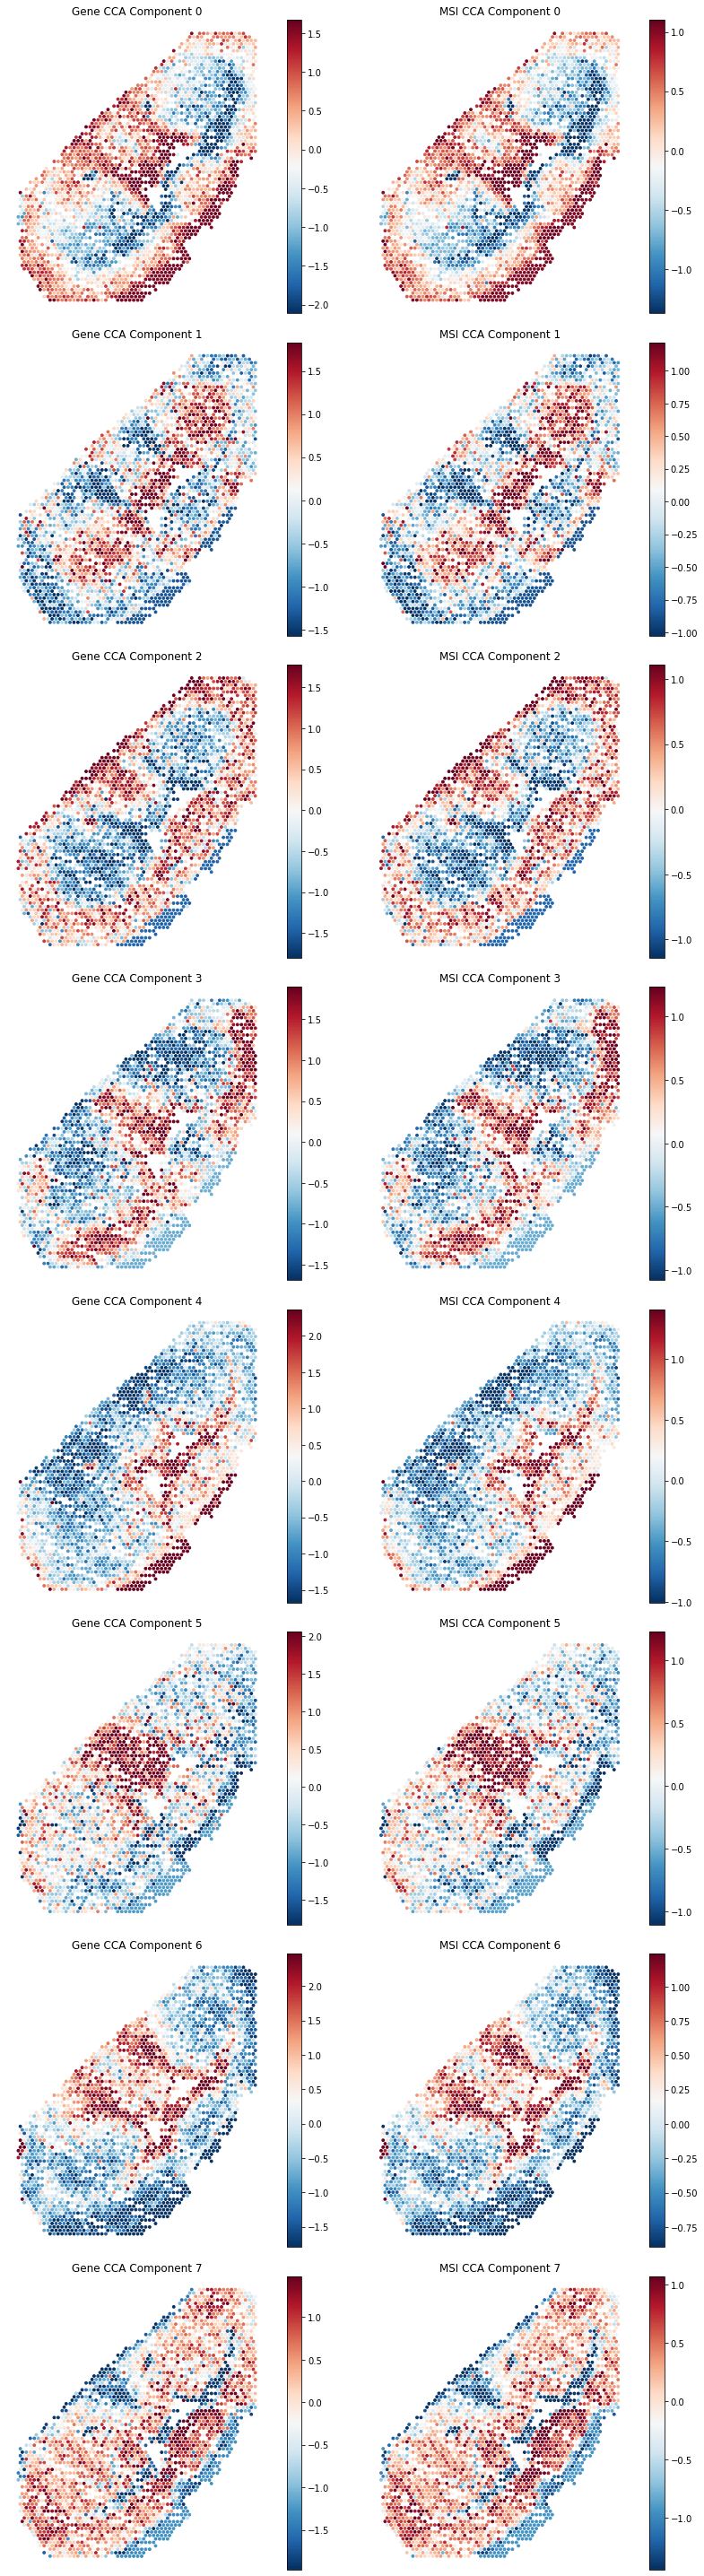

In [21]:
fig, axes = plt.subplots(8, 2, figsize=(12, 40))
for i in range(8):
    for col_idx, (key, label) in enumerate([("cca_gene", "Gene CCA"), ("cca_msi", "MSI CCA")]):
        ax  = axes[i, col_idx]
        col = df[f"{key}_{i}"]
        sc  = ax.scatter(df["x"], df["y"], c=col, cmap="RdBu_r",
                         vmin=np.percentile(col, 5), vmax=np.percentile(col, 95), s=8)
        plt.colorbar(sc, ax=ax)
        ax.set_title(f"{label} Component {i}")
        ax.set_aspect("equal")
        ax.axis("off")

plt.tight_layout()
plt.savefig("/Users/mridulav/spatial_cca_components2.png", dpi=150)
plt.show()

In [23]:
best_comp = 6

sig_genes = gene_corrs_all[best_comp][gene_corrs_all[best_comp]["r_abs"] > 0.25]["gene"].tolist()
sig_msi   = msi_corrs_all[best_comp][msi_corrs_all[best_comp]["r_abs"] > 0.5]["msi"].tolist()

print("Sig genes:", len(sig_genes))
print("Sig msi:", len(sig_msi))

pairs = pd.DataFrame([
    {"gene": g, "msi": m, "component": best_comp,
     "r": pearsonr(X[:, gene_names.index(g)], Y[:, msi_names.index(m)])[0]}
    for g in sig_genes for m in sig_msi
]).assign(r_abs=lambda d: d["r"].abs()).sort_values("r_abs", ascending=False)

print(pairs.head(20)[["gene", "msi", "r"]].to_string(index=False))
pairs.to_csv("/Users/mridulav/gene_metabolite_pairs_mouse_V11L12_038_B1.csv", index=False)

Sig genes: 69
Sig msi: 18
  gene                   msi         r
  Nrgn         mz.297.070615 -0.473027
  Nrgn mz.296.06595500000003 -0.469533
  Nrgn         mz.258.110295 -0.467648
  Nrgn         mz.516.190135 -0.467596
  Nrgn  mz.592.0904700000001 -0.467503
  Nrgn         mz.297.069625 -0.457657
  Nrgn         mz.298.062905 -0.455165
  Nrgn          mz.394.12496 -0.453440
  Nrgn mz.298.06399999999996 -0.448902
  Nrgn          mz.297.06824 -0.440617
  Nrgn         mz.280.092375 -0.435763
  Nrgn  mz.560.1485299999999 -0.431400
  Nrgn         mz.298.065095 -0.430772
  Nrgn mz.259.11330999999996 -0.423046
   Cck         mz.516.190135 -0.407002
  Nrgn         mz.259.113915 -0.400688
Cdr1os         mz.516.190135 -0.399402
Cdr1os         mz.258.110295 -0.398270
   Cck         mz.258.110295 -0.396277
  Nrgn          mz.592.09793 -0.394860
